# Amazon Sales Analysis

## Overview

This project analyzes Amazon sales data to identify sales trends, product performance, regional performance, payment preferences, and other business insights using Python.

## 1. Data Loading and Understanding

In this section, the dataset is loaded and basic information about the data is examined.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Amazon_Sales_Dataset.csv")

print("Dataset loaded successfully!")
print("Rows and Columns:", df.shape)

df.head()

Dataset loaded successfully!
Rows and Columns: (5000, 15)


,Order ID,Order Date,Customer ID,Customer Name,Region,Product Category,Product Name,Quantity Sold,Unit Price,Discount (%),Salesperson,Payment Method,Order Status,Total Sales,Profit Margin
0,576ca8db-ad1a-4aa8-9c3a-89102555f200,2019-01-01,48aa940a-5cb5-4103-8d89-19c10fd26aaf,Stephanie Garcia,South America,Home & Kitchen,Speak,9,484.46,21.33,Johnny Marshall,Debit Card,Returned,3430.12,1193.53
1,b7154d7e-f369-4a81-80b1-d36b23cc0420,2019-01-01,8de3545c-78e6-4962-ace5-02e37fe1ce91,Jacob Morales,South America,Books,If,10,179.28,6.43,Bradley Howe,Gift Card,Pending,1677.52,583.70
2,b2852522-fbaa-43fa-b165-bd10e0035591,2019-01-02,6ac41f61-acf6-4e46-8b70-ad00ce01c9d0,John Carroll,North America,Sports,Big,6,185.34,1.57,Johnny Marshall,Amazon Pay,Completed,1094.58,380.86
3,f14eae78-235f-4283-a2cc-6433fd861c14,2019-01-04,04bb6a6a-a62a-4e79-a038-68758f215ccc,Allison Ramirez,Asia,Home & Kitchen,Serious,5,40.98,4.21,Roger Brown,PayPal,Completed,196.27,68.29
4,c3fcb6f0-a399-47eb-8903-2a354425ea75,2019-01-04,2267ce03-37ba-446a-b279-17ecee550c6e,James Thompson,North America,Toys,Operation,10,459.39,20.50,Kristen Ramos,PayPal,Cancelled,3652.15,1270.78


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          5000 non-null   object 
 1   Order Date        5000 non-null   object 
 2   Customer ID       5000 non-null   object 
 3   Customer Name     5000 non-null   object 
 4   Region            5000 non-null   object 
 5   Product Category  5000 non-null   object 
 6   Product Name      4999 non-null   object 
 7   Quantity Sold     5000 non-null   int64  
 8   Unit Price        5000 non-null   float64
 9   Discount (%)      5000 non-null   float64
 10  Salesperson       5000 non-null   object 
 11  Payment Method    5000 non-null   object 
 12  Order Status      5000 non-null   object 
 13  Total Sales       5000 non-null   float64
 14  Profit Margin     5000 non-null   float64
dtypes: float64(4), int64(1), object(10)
memory usage: 586.1+ KB


## 2. Data Quality Check

This section checks the dataset for missing values and potential data quality issues before performing further analysis.

In [ ]:
df.isnull().sum()

,0
Order ID,0
Order Date,0
Customer ID,0
Customer Name,0
Region,0
Product Category,0
Product Name,1
Quantity Sold,0
Unit Price,0
Discount (%),0


In [ ]:
df[df["Product Name"].isnull()]

,Order ID,Order Date,Customer ID,Customer Name,Region,Product Category,Product Name,Quantity Sold,Unit Price,Discount (%),Salesperson,Payment Method,Order Status,Total Sales,Profit Margin
137,e8d745a9-e084-4d87-9b1b-40b2b1db0a2f,2019-03-04,4ff9f9d6-cf44-4246-9f5f-6e70b530e1a6,Zachary Nguyen,Asia,Toys,NaN,10,144.72,2.62,Bradley Howe,Credit Card,Completed,1409.28,490.37


In [ ]:
df["Product Name"] = df["Product Name"].fillna("Unknown")

In [ ]:
df.duplicated().sum()

np.int64(0)

## 3. Descriptive Statistics

This section summarizes the numerical variables in the dataset, including sales, quantity sold, unit price, discount, and profit margin.

In [ ]:
df.describe()

,Quantity Sold,Unit Price,Discount (%),Total Sales,Profit Margin
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,5.518800,255.161728,14.899920,1187.145384,413.072520
std,2.896088,143.167691,8.705621,988.464586,343.940683
min,1.000000,5.160000,0.000000,4.610000,1.600000
25%,3.000000,130.112500,7.237500,370.127500,128.787500
50%,6.000000,257.080000,14.870000,907.955000,315.930000
75%,8.000000,379.710000,22.442500,1762.252500,613.180000
max,10.000000,499.910000,29.990000,4911.920000,1709.120000


## 4. Product Category Analysis

This section compares total sales across different product categories to identify the strongest and weakest performing categories.

In [ ]:
category_sales = df.groupby("Product Category")["Total Sales"].sum()

category_sales

,Total Sales
Product Category,
Beauty,794056.99
Books,814614.05
Clothing,874698.53
Electronics,854348.56
Home & Kitchen,837059.82
Sports,894838.14
Toys,866110.83


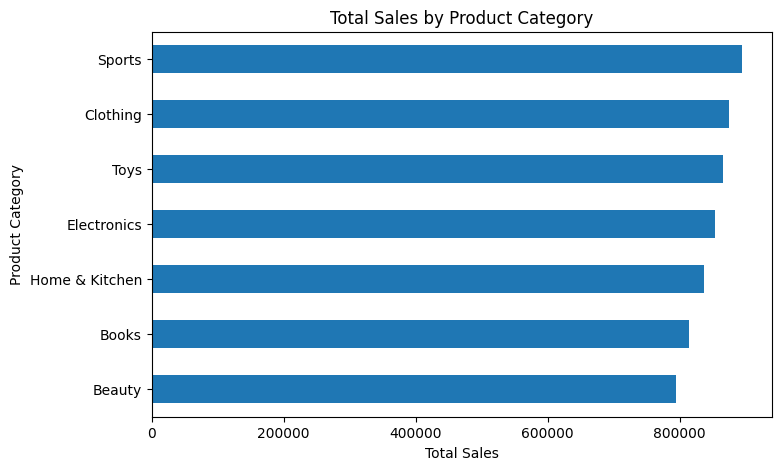

In [ ]:
plt.figure(figsize=(8, 5))

category_sales.sort_values().plot(kind="barh")

plt.title("Total Sales by Product Category")
plt.xlabel("Total Sales")
plt.ylabel("Product Category")

plt.show()

## 5. Regional Sales Analysis

This section analyzes total sales across different regions to identify the strongest markets and compare regional performance.

In [ ]:
region_sales = df.groupby("Region")["Total Sales"].sum()

region_sales

,Total Sales
Region,
Asia,1215239.51
Australia,1164771.22
Europe,1160480.98
North America,1073059.87
South America,1322175.34


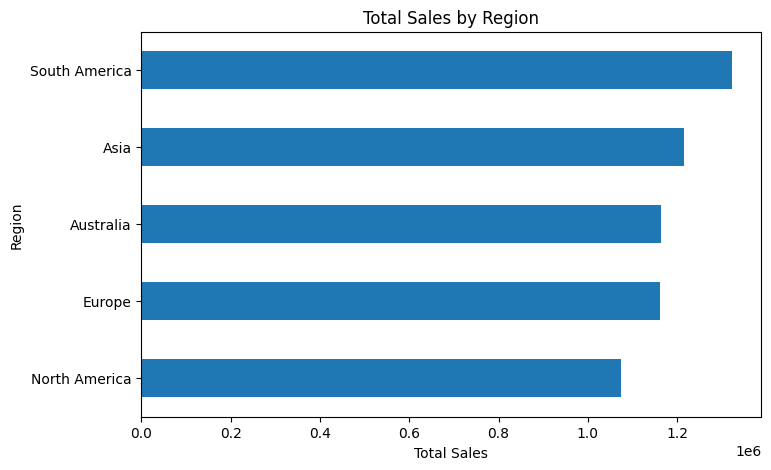

In [ ]:
plt.figure(figsize=(8, 5))

region_sales.sort_values().plot(kind="barh")

plt.title("Total Sales by Region")
plt.xlabel("Total Sales")
plt.ylabel("Region")

plt.show()

## 6. Monthly Sales Trend

This section analyzes monthly sales performance to identify changes, fluctuations, and overall sales trends over time.

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Total Sales"].sum()

monthly_sales.head()

,Total Sales
Order Date,
2019-01,86731.98
2019-02,70990.77
2019-03,82256.33
2019-04,77205.55
2019-05,90999.19


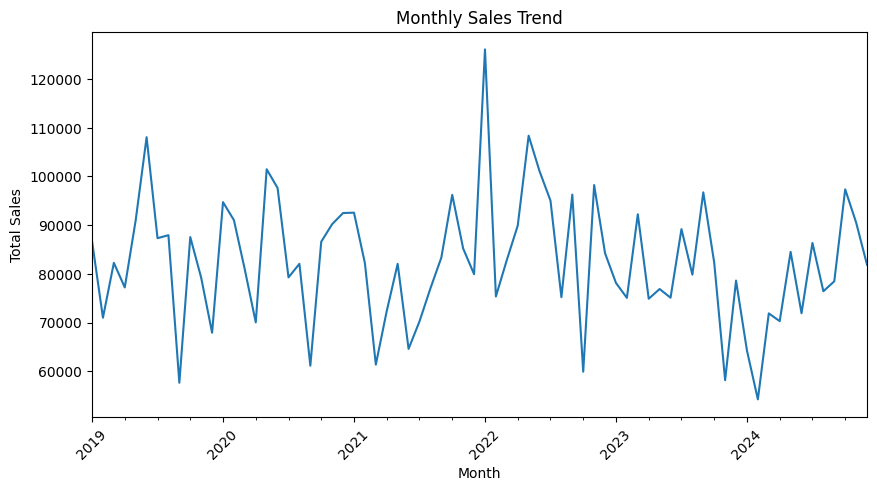

In [ ]:
plt.figure(figsize=(10, 5))

monthly_sales.plot(kind="line")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.show()

## 7. Order Status Analysis

This section examines the distribution of order statuses to understand completed, returned, pending, and cancelled orders.

In [ ]:
status_count = df["Order Status"].value_counts()

status_count

,count
Order Status,
Returned,1325
Completed,1232
Pending,1227
Cancelled,1216


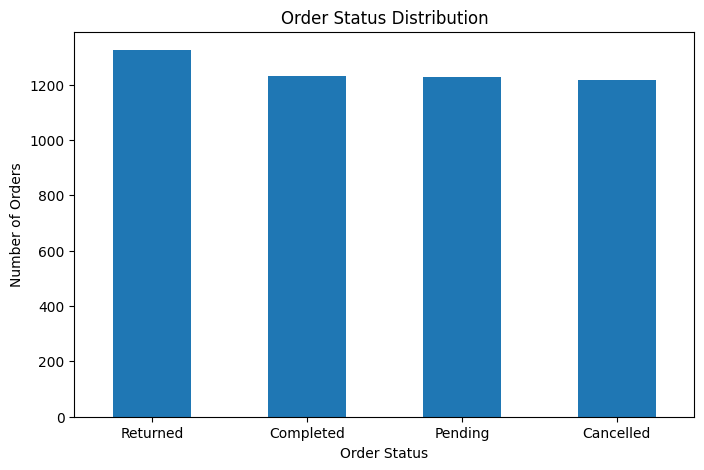

In [ ]:
plt.figure(figsize=(8, 5))

status_count.plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)
plt.show()

## 8. Payment Method Analysis

This section analyzes customer payment preferences by comparing the number of orders made through different payment methods.

In [ ]:
payment_count = df["Payment Method"].value_counts()

payment_count

,count
Payment Method,
Debit Card,1043
Amazon Pay,1018
PayPal,1009
Gift Card,969
Credit Card,961


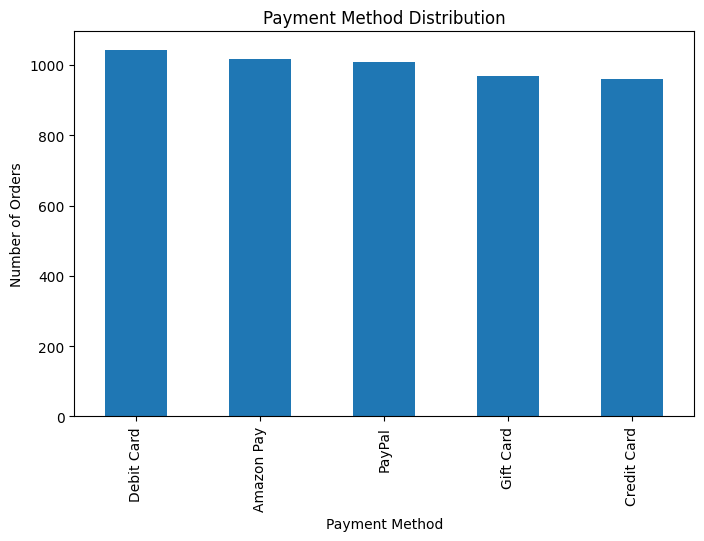

In [ ]:
plt.figure(figsize=(8, 5))

payment_count.plot(kind="bar")

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.show()

## 9. Profitability by Product Category

This section compares profit margin across product categories to identify the categories contributing most to overall profitability.

In [ ]:
category_profit = df.groupby("Product Category")["Profit Margin"].sum()

category_profit

,Profit Margin
Product Category,
Beauty,276295.67
Books,283448.68
Clothing,304355.12
Electronics,297274.43
Home & Kitchen,291258.65
Sports,311362.98
Toys,301367.07


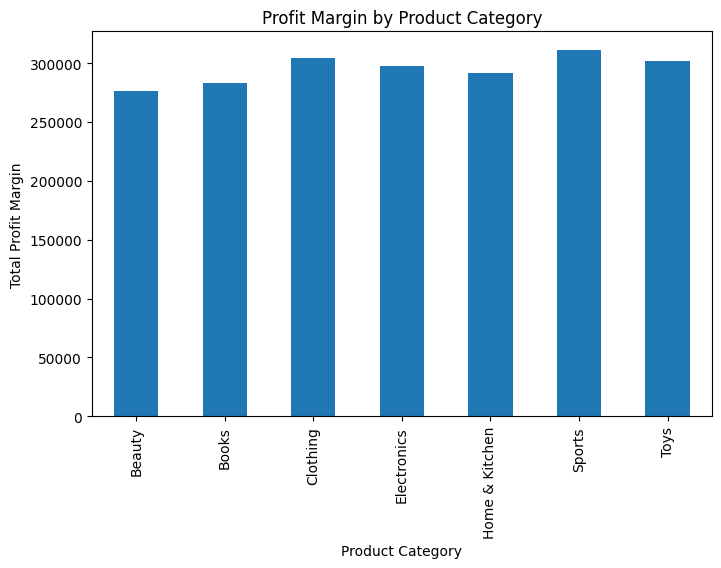

In [ ]:
plt.figure(figsize=(8, 5))

category_profit.plot(kind="bar")

plt.title("Profit Margin by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Profit Margin")

plt.show()

## 10. Top Products Analysis

This section identifies the top-performing products based on total sales and highlights the products contributing most to overall revenue.

In [ ]:
product_sales = df.groupby("Product Name")["Total Sales"].sum()

top_products = product_sales.sort_values(ascending=False).head(10)

top_products

,Total Sales
Product Name,
Present,24650.30
If,19107.97
Strategy,17599.05
Relate,17054.00
Show,16979.88
Trial,16891.42
Leader,16696.36
Almost,16430.68
Improve,16382.64


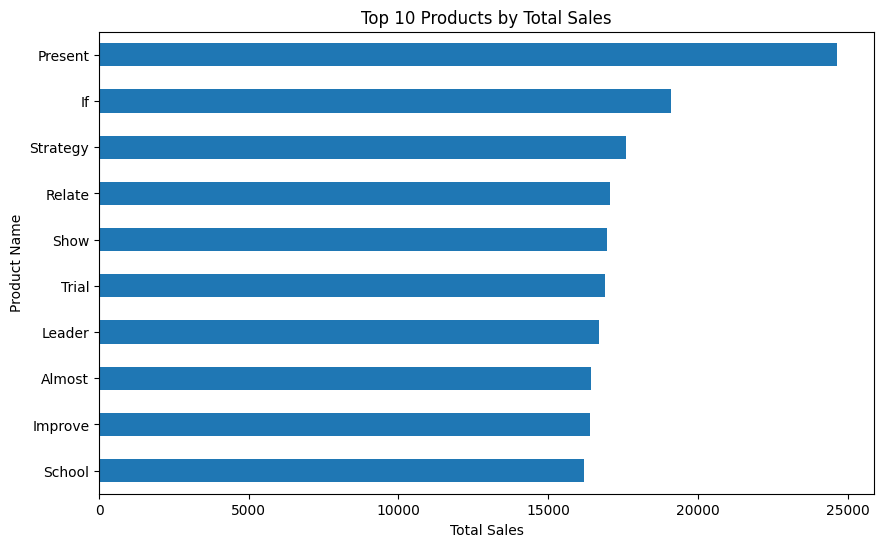

In [ ]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")

plt.show()

In [ ]:
total_sales = df["Total Sales"].sum()
total_quantity = df["Quantity Sold"].sum()
average_sales = df["Total Sales"].mean()
average_discount = df["Discount (%)"].mean()
average_profit = df["Profit Margin"].mean()

print("Total Sales:", round(total_sales, 2))
print("Total Quantity Sold:", total_quantity)
print("Average Order Value:", round(average_sales, 2))
print("Average Discount:", round(average_discount, 2), "%")
print("Average Profit Margin:", round(average_profit, 2))

Total Sales: 5935726.92
Total Quantity Sold: 27594
Average Order Value: 1187.15
Average Discount: 14.9 %
Average Profit Margin: 413.07


In [ ]:
category_quantity = df.groupby("Product Category")["Quantity Sold"].sum()

category_quantity

,Quantity Sold
Product Category,
Beauty,3749
Books,3781
Clothing,4079
Electronics,3959
Home & Kitchen,3895
Sports,4153
Toys,3978


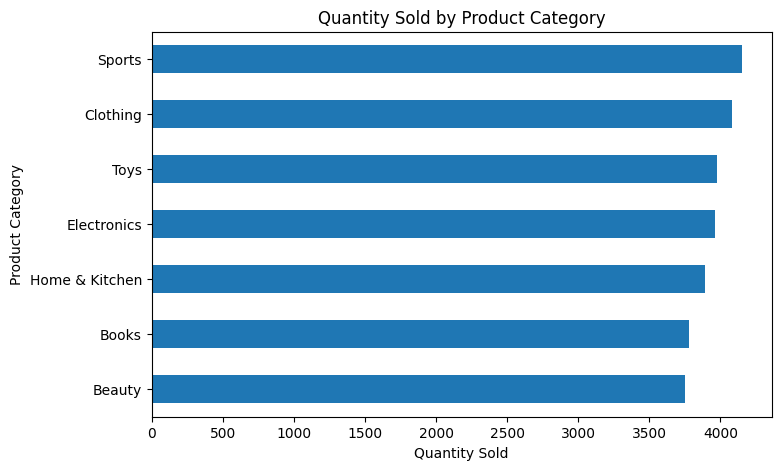

In [ ]:
plt.figure(figsize=(8, 5))

category_quantity.sort_values().plot(kind="barh")

plt.title("Quantity Sold by Product Category")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Category")

plt.show()

In [ ]:
df["Discount (%)"].describe()

,Discount (%)
count,5000.000000
mean,14.899920
std,8.705621
min,0.000000
25%,7.237500
50%,14.870000
75%,22.442500
max,29.990000


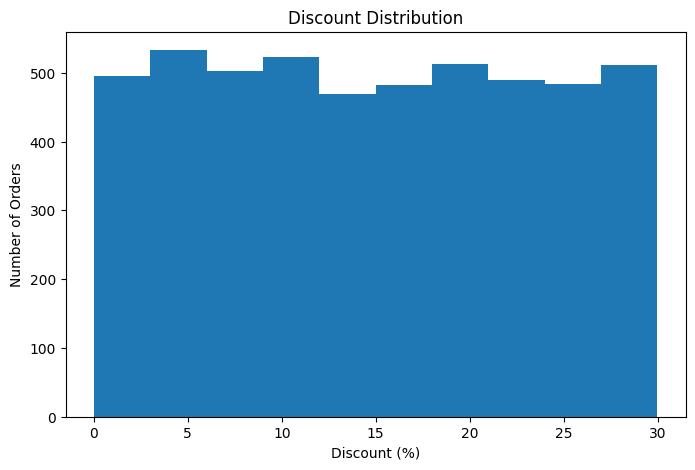

In [ ]:
plt.figure(figsize=(8, 5))

df["Discount (%)"].plot(kind="hist", bins=10)

plt.title("Discount Distribution")
plt.xlabel("Discount (%)")
plt.ylabel("Number of Orders")

plt.show()

## 11. Salesperson Performance Analysis

This section compares total sales generated by each salesperson to identify high-performing and low-performing sales representatives.

In [ ]:
salesperson_sales = df.groupby("Salesperson")["Total Sales"].sum()

salesperson_sales

,Total Sales
Salesperson,
Adam Smith,240739.97
Bradley Howe,302155.63
Caitlyn Boyd,290741.96
Caleb Camacho,321688.20
Charles Smith,313913.49
Christina Thompson,268525.60
Crystal Williams,298201.61
Diane Andrews,328230.18
Emily Matthews,315982.41


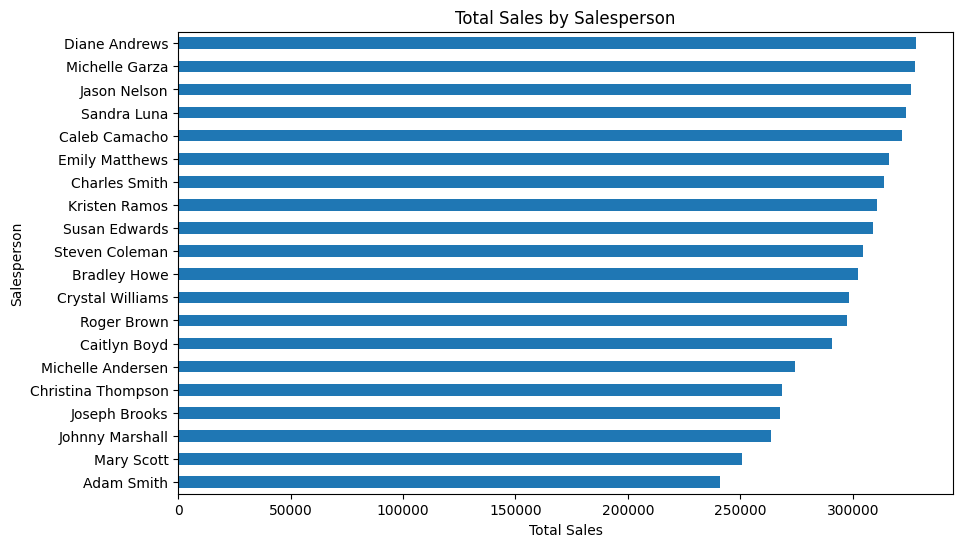

In [ ]:
plt.figure(figsize=(10, 6))

salesperson_sales.sort_values().plot(kind="barh")

plt.title("Total Sales by Salesperson")
plt.xlabel("Total Sales")
plt.ylabel("Salesperson")

plt.show()

In [ ]:
category_data = df.groupby("Product Category")[["Total Sales", "Quantity Sold"]].sum()

category_data

,Total Sales,Quantity Sold
Product Category,,
Beauty,794056.99,3749
Books,814614.05,3781
Clothing,874698.53,4079
Electronics,854348.56,3959
Home & Kitchen,837059.82,3895
Sports,894838.14,4153
Toys,866110.83,3978


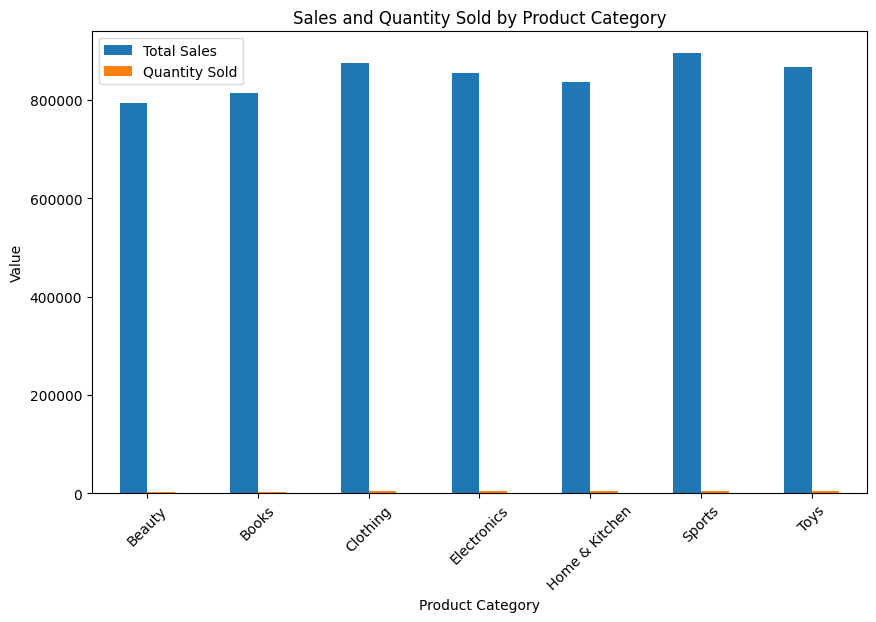

In [ ]:
category_data.plot(kind="bar", figsize=(10, 6))

plt.title("Sales and Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Value")

plt.xticks(rotation=45)
plt.show()

In [ ]:
payment_sales = df.groupby("Payment Method")["Total Sales"].sum()

payment_sales

,Total Sales
Payment Method,
Amazon Pay,1249239.53
Credit Card,1113302.73
Debit Card,1257289.10
Gift Card,1114751.38
PayPal,1201144.18


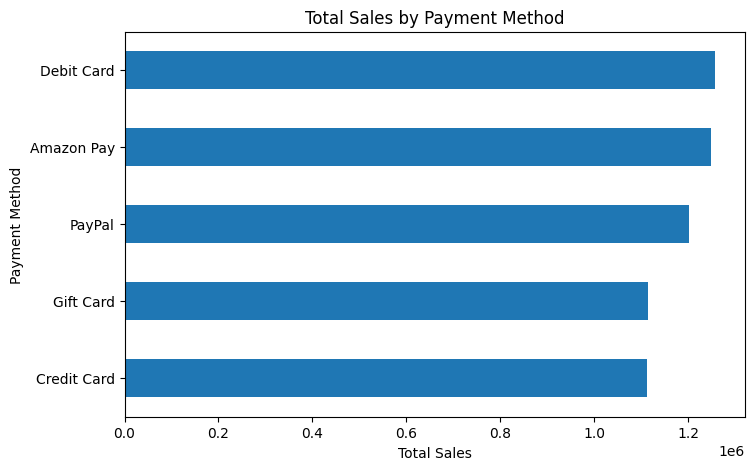

In [ ]:
plt.figure(figsize=(8, 5))

payment_sales.sort_values().plot(kind="barh")

plt.title("Total Sales by Payment Method")
plt.xlabel("Total Sales")
plt.ylabel("Payment Method")

plt.show()

In [ ]:
category_discount = df.groupby("Product Category")["Discount (%)"].mean()

category_discount

,Discount (%)
Product Category,
Beauty,15.058412
Books,15.328367
Clothing,14.524980
Electronics,14.918986
Home & Kitchen,14.404530
Sports,14.972286
Toys,15.115090


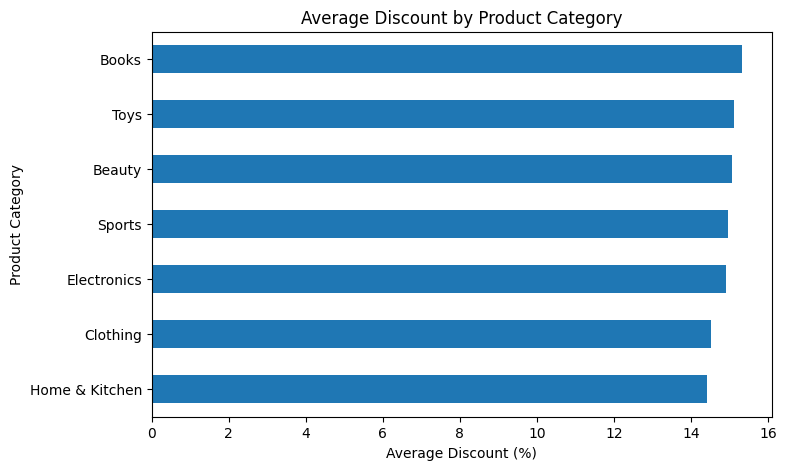

In [ ]:
plt.figure(figsize=(8, 5))

category_discount.sort_values().plot(kind="barh")

plt.title("Average Discount by Product Category")
plt.xlabel("Average Discount (%)")
plt.ylabel("Product Category")

plt.show()

In [ ]:
monthly_quantity = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Quantity Sold"].sum()

monthly_quantity

,Quantity Sold
Order Date,
2019-01,359
2019-02,373
2019-03,384
2019-04,347
2019-05,370
...,...
2024-08,418
2024-09,389
2024-10,440


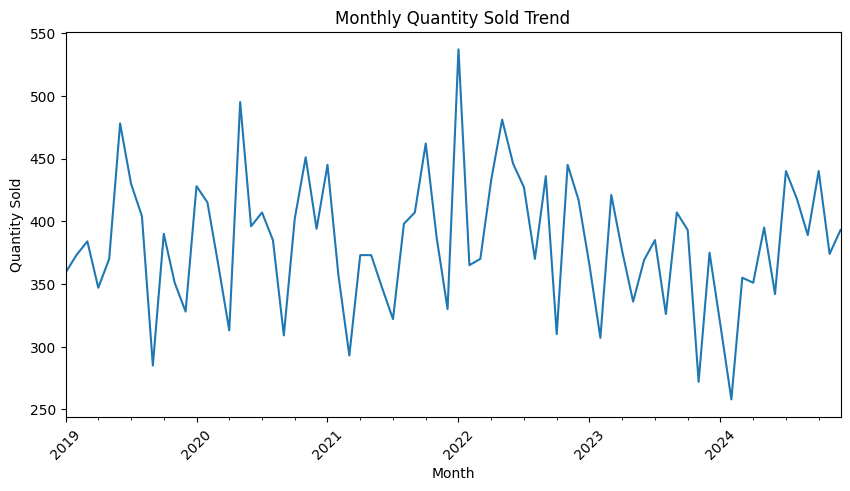

In [ ]:
plt.figure(figsize=(10, 5))

monthly_quantity.plot(kind="line")

plt.title("Monthly Quantity Sold Trend")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=45)
plt.show()

In [ ]:
salesperson_profit = df.groupby("Salesperson")["Profit Margin"].sum()

salesperson_profit

,Profit Margin
Salesperson,
Adam Smith,83766.58
Bradley Howe,105136.45
Caitlyn Boyd,101164.96
Caleb Camacho,111932.91
Charles Smith,109227.53
Christina Thompson,93434.67
Crystal Williams,103760.58
Diane Andrews,114209.11
Emily Matthews,109947.53


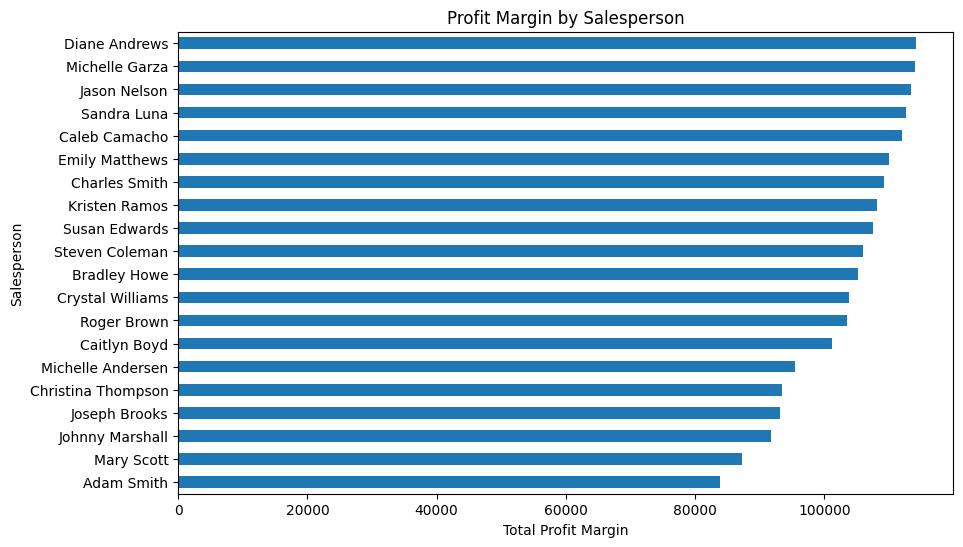

In [ ]:
plt.figure(figsize=(10, 6))

salesperson_profit.sort_values().plot(kind="barh")

plt.title("Profit Margin by Salesperson")
plt.xlabel("Total Profit Margin")
plt.ylabel("Salesperson")

plt.show()

In [ ]:
region_profit = df.groupby("Region")["Profit Margin"].sum()

region_profit

,Profit Margin
Region,
Asia,422847.97
Australia,405287.43
Europe,403794.47
North America,373375.87
South America,460056.86


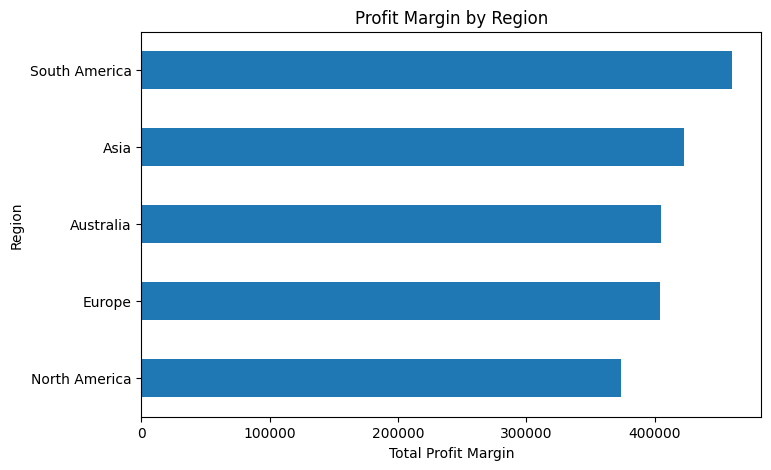

In [ ]:
plt.figure(figsize=(8, 5))

region_profit.sort_values().plot(kind="barh")

plt.title("Profit Margin by Region")
plt.xlabel("Total Profit Margin")
plt.ylabel("Region")

plt.show()

In [ ]:
top_quantity_products = df.groupby("Product Name")["Quantity Sold"].sum()

top_quantity_products = top_quantity_products.sort_values(
    ascending=False
).head(10)

top_quantity_products

,Quantity Sold
Product Name,
Present,88
Improve,86
If,78
Show,75
Relate,72
Region,71
Fish,71
Fund,70
Strategy,69


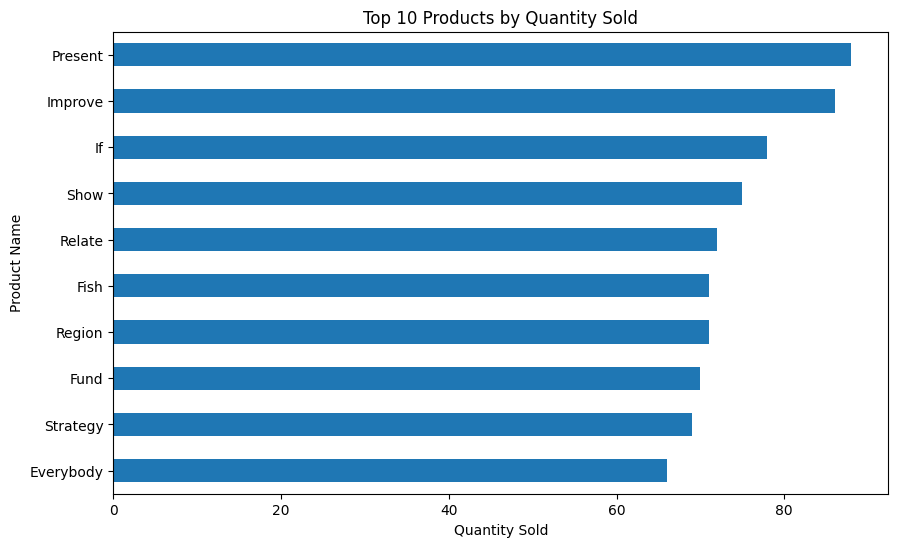

In [ ]:
plt.figure(figsize=(10, 6))

top_quantity_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Name")

plt.show()

In [ ]:
df["Unit Price"].describe()

,Unit Price
count,5000.000000
mean,255.161728
std,143.167691
min,5.160000
25%,130.112500
50%,257.080000
75%,379.710000
max,499.910000


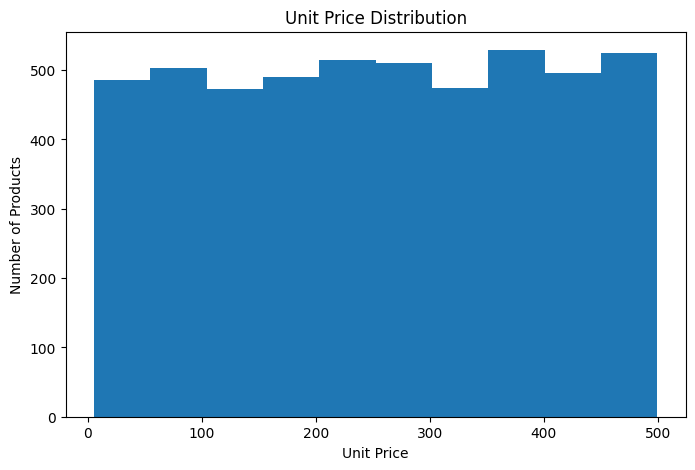

In [ ]:
plt.figure(figsize=(8, 5))

df["Unit Price"].plot(kind="hist", bins=10)

plt.title("Unit Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Number of Products")

plt.show()

In [ ]:
sales_profit = df[["Total Sales", "Profit Margin"]]

sales_profit.corr()

,Total Sales,Profit Margin
Total Sales,1.0,1.0
Profit Margin,1.0,1.0


In [ ]:
status_sales = df.groupby("Order Status")["Total Sales"].sum()

status_sales

,Total Sales
Order Status,
Cancelled,1440091.42
Completed,1477510.68
Pending,1445493.01
Returned,1572631.81


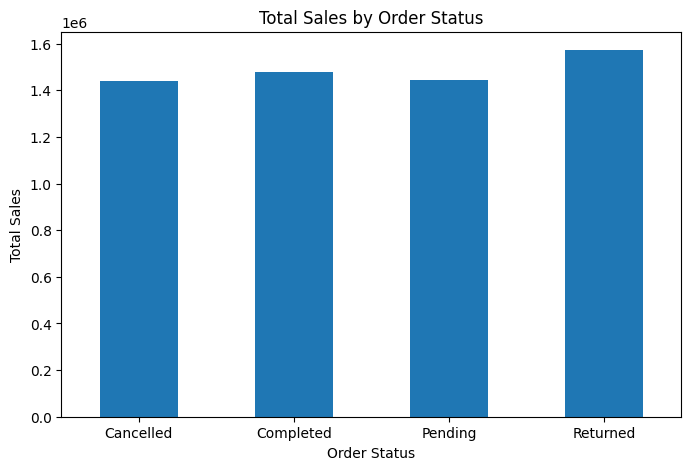

In [ ]:
plt.figure(figsize=(8, 5))

status_sales.plot(kind="bar")

plt.title("Total Sales by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)
plt.show()

In [ ]:
yearly_sales = df.groupby(
    df["Order Date"].dt.year
)["Total Sales"].sum()

yearly_sales

,Total Sales
Order Date,
2019,983770.92
2020,1027440.74
2021,947003.55
2022,1092444.59
2023,957082.38
2024,927984.74


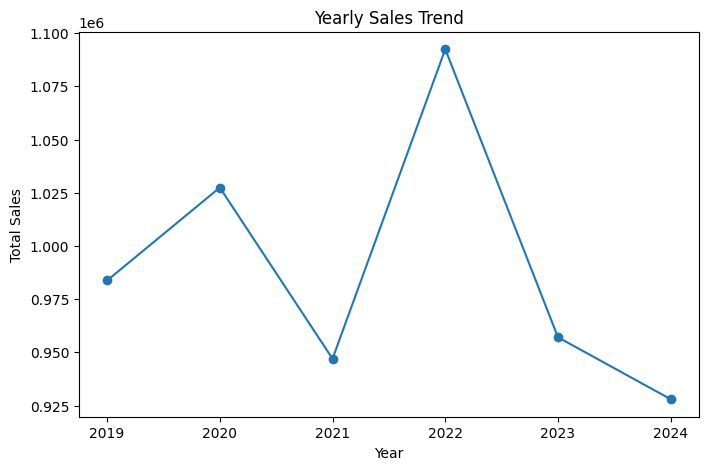

In [ ]:
plt.figure(figsize=(8, 5))

yearly_sales.plot(kind="line", marker="o")

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

In [ ]:
yearly_quantity = df.groupby(
    df["Order Date"].dt.year
)["Quantity Sold"].sum()

yearly_quantity

,Quantity Sold
Order Date,
2019,4499
2020,4760
2021,4494
2022,5037
2023,4332
2024,4472


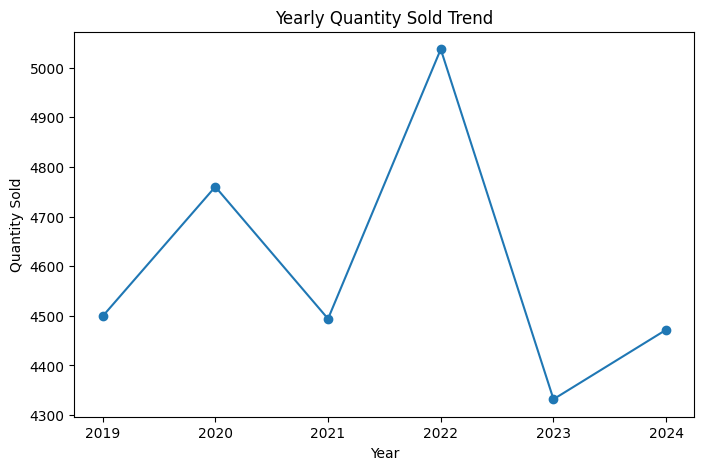

In [ ]:
plt.figure(figsize=(8, 5))

yearly_quantity.plot(kind="line", marker="o")

plt.title("Yearly Quantity Sold Trend")
plt.xlabel("Year")
plt.ylabel("Quantity Sold")

plt.show()

In [ ]:
yearly_average_sales = df.groupby(
    df["Order Date"].dt.year
)["Total Sales"].mean()

yearly_average_sales

,Total Sales
Order Date,
2019,1219.046989
2020,1200.281238
2021,1174.942370
2022,1215.177519
2023,1220.768342
2024,1094.321627


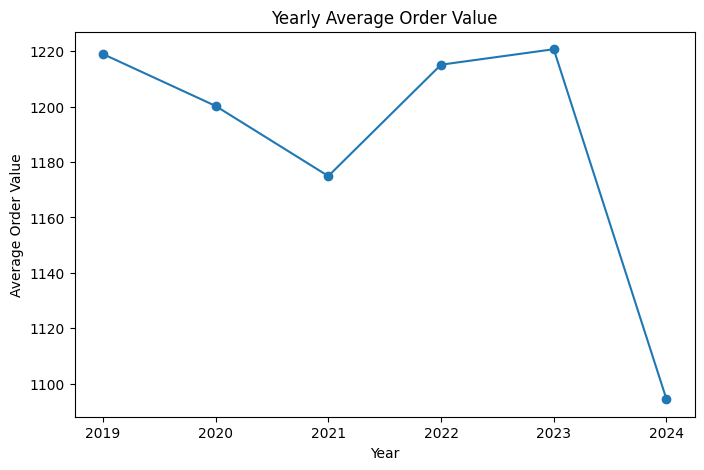

In [ ]:
plt.figure(figsize=(8, 5))

yearly_average_sales.plot(kind="line", marker="o")

plt.title("Yearly Average Order Value")
plt.xlabel("Year")
plt.ylabel("Average Order Value")

plt.show()

In [ ]:
category_region_sales = df.groupby(
    ["Region", "Product Category"]
)["Total Sales"].sum()

category_region_sales

Region         Product Category
Asia           Beauty              195875.18
               Books               180569.63
               Clothing            156305.47
               Electronics         174750.43
               Home & Kitchen      162292.68
               Sports              187432.97
               Toys                158013.15
Australia      Beauty              155226.37
               Books               141971.85
               Clothing            169625.25
               Electronics         178580.91
               Home & Kitchen      164334.49
               Sports              173655.41
               Toys                181376.94
Europe         Beauty              138768.47
               Books               149874.08
               Clothing            176960.16
               Electronics         160566.26
               Home & Kitchen      189224.25
               Sports              173145.89
               Toys                171941.87
North America  Beauty              143878.57
               Books               141774.26
               Clothing            168864.32
               Electronics         153956.25
               Home & Kitchen      137919.90
               Sports              156095.93
               Toys                170570.64
South America  Beauty              160308.40
               Books               200424.23
               Clothing            202943.33
               Electronics         186494.71
               Home & Kitchen      183288.50
               Sports              204507.94
               Toys                184208.23
Name: Total Sales, dtype: float64

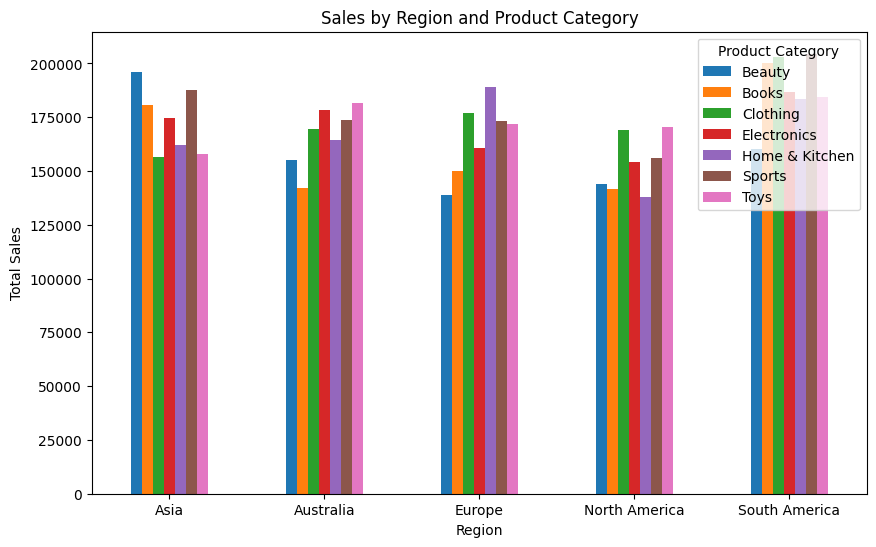

In [ ]:
category_region_sales.unstack().plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales by Region and Product Category")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)
plt.show()

In [ ]:
category_region_sales.sort_values(ascending=False).head(10)

Region         Product Category
South America  Sports              204507.94
               Clothing            202943.33
               Books               200424.23
Asia           Beauty              195875.18
Europe         Home & Kitchen      189224.25
Asia           Sports              187432.97
South America  Electronics         186494.71
               Toys                184208.23
               Home & Kitchen      183288.50
Australia      Toys                181376.94
Name: Total Sales, dtype: float64

In [ ]:
customer_sales = df.groupby("Customer Name")["Total Sales"].sum()

top_customers = customer_sales.sort_values(
    ascending=False
).head(10)

top_customers

,Total Sales
Customer Name,
Jennifer Wright,6304.86
Anthony Johnson,5618.30
Christine Robinson,5576.58
Michael Clark,5368.75
Michael Smith,5232.61
Stephanie Garcia,5219.76
Christopher Smith,5144.21
Brandy Smith,5062.35
Christopher Robinson,4946.68


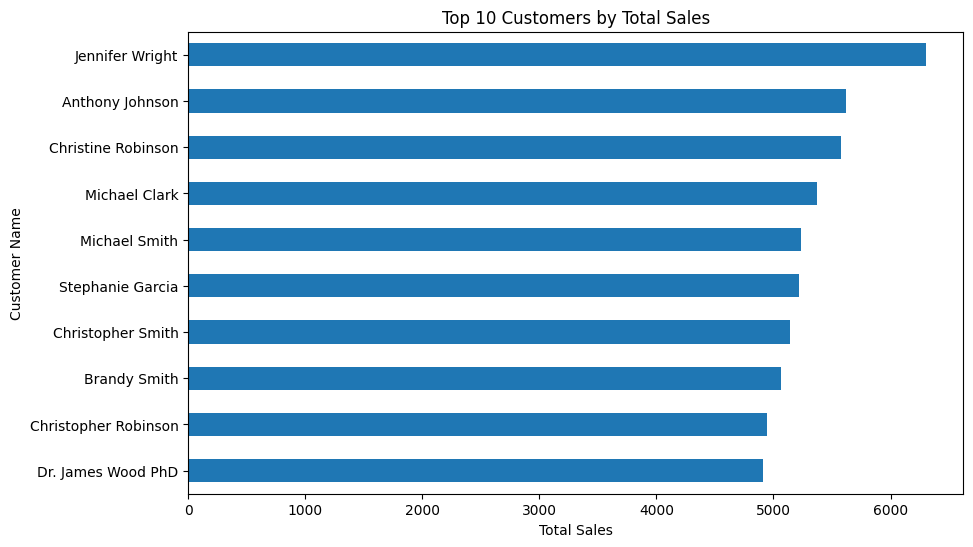

In [ ]:
plt.figure(figsize=(10, 6))

top_customers.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer Name")

plt.show()

## 12. Profitability Analysis

This section identifies the products generating the highest total profit margin and highlights the most profitable products in the dataset.

In [ ]:
top_profit_products = df.groupby("Product Name")["Profit Margin"].sum().sort_values(ascending=False).head(10)

top_profit_products

,Profit Margin
Product Name,
Present,8577.19
If,6648.71
Strategy,6123.68
Relate,5934.01
Show,5908.21
Trial,5877.43
Leader,5809.57
Almost,5717.12
Improve,5700.42


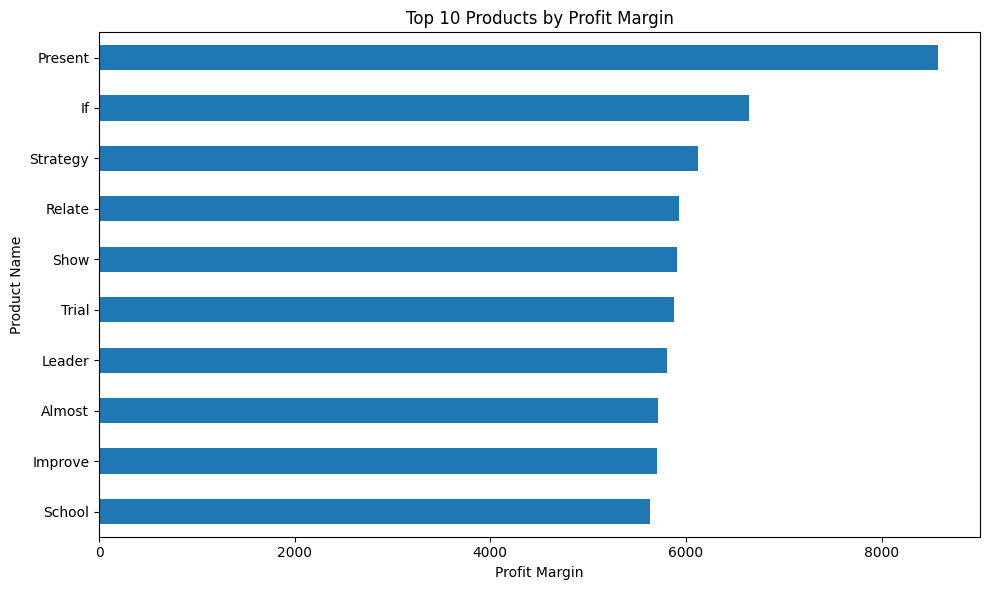

In [ ]:
plt.figure(figsize=(10, 6))

top_profit_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Profit Margin")
plt.xlabel("Profit Margin")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

## 13. Key Performance Indicators (KPIs)

This section summarizes the key performance indicators of the Amazon sales dataset, providing an overall view of sales, order quantity, average order value, discount, and profitability.

In [ ]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Quantity Sold",
        "Average Order Value",
        "Average Discount",
        "Average Profit Margin"
    ],
    "Value": [
        df["Total Sales"].sum(),
        df["Quantity Sold"].sum(),
        df["Total Sales"].mean(),
        df["Discount (%)"].mean(),
        df["Profit Margin"].mean()
    ]
})

kpi_summary["Value"] = kpi_summary["Value"].round(2)

kpi_summary

,Metric,Value
0,Total Sales,5935726.92
1,Total Quantity Sold,27594.00
2,Average Order Value,1187.15
3,Average Discount,14.90
4,Average Profit Margin,413.07


## Key Business Insights

- Sports generated the highest total sales among all product categories, with total sales of approximately $894.84K.

- South America recorded the highest total sales among all regions, generating approximately $1.32M.

- 2022 was the strongest sales year in the dataset, with total sales of approximately $1.09M.

- Debit Card generated the highest total sales among the available payment methods, with approximately $1.26M in sales.

- Sports recorded the highest total profit margin value among all product categories, at approximately $311.36K.

- The dataset recorded total sales of approximately $5.94M across 27,594 units sold.

- The average order value in the dataset was approximately $1,187.15, while the average discount was approximately 14.90%.

## Business Recommendations

- Focus more on high-performing product categories such as Sports while continuing to monitor the performance of other categories.

- Investigate the reasons behind strong sales in South America and identify strategies that can be applied to other regions.

- Analyze the factors that contributed to the strong sales performance in 2022 and use these findings for future planning.

- Continue supporting popular payment methods such as Debit Card while monitoring customer preferences across other payment options.

- Review discount strategies carefully to ensure that discounts increase sales without negatively affecting profitability.

- Monitor returned and cancelled orders to identify possible issues with products, delivery, or customer experience.

## 14. Conclusion

This analysis provides an overall view of Amazon sales performance across products, regions, payment methods, order statuses, salespersons, and profitability. The findings help identify business trends, top-performing areas, and opportunities for data-driven decision-making.